In [6]:
import pandas as pd
import numpy as np

sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")


sentiment.info()
trades.info()

sentiment.isna().sum()
trades.isna().sum()


sentiment.duplicated().sum()
trades.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

np.int64(0)

In [8]:
print(trades.columns)
print(sentiment.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [12]:
trades['time'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['time'].dt.date

In [14]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date


In [15]:
print(trades[['time', 'date']].head())
print(sentiment[['date']].head())


                 time        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05


In [19]:
# STEP 3: Daily trader-level metrics

daily_metrics = (
    trades
    .groupby(['Account', 'date'])
    .agg(
        daily_pnl=('Closed PnL', 'sum'),
        trades_count=('Coin', 'count'),
        avg_trade_size=('Size USD', 'mean'),
        long_trades=('Side', lambda x: (x == 'BUY').sum()),
        short_trades=('Side', lambda x: (x == 'SELL').sum())
    )
    .reset_index()
)

# ratio
daily_metrics['long_short_ratio'] = (
    daily_metrics['long_trades'] /
    (daily_metrics['short_trades'] + 1)
)

daily_metrics.head()

,Account,date,daily_pnl,trades_count,avg_trade_size,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,139,323,0.429012
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,1572,1784,0.880672
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,145,175,0.823864
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,1528,2005,0.761715
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,1382,2045,0.675464


In [20]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [21]:
final_df = daily_metrics.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)


In [22]:
final_df.head()


,Account,date,daily_pnl,trades_count,avg_trade_size,long_trades,short_trades,long_short_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,139,323,0.429012,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,1572,1784,0.880672,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,145,175,0.823864,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,1528,2005,0.761715,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,1382,2045,0.675464,NaN


In [23]:
analysis_df = final_df.dropna(subset=['classification'])


In [24]:
analysis_df['classification'].value_counts()


,count
classification,
Greed,32
Fear,32
Neutral,8
Extreme Greed,5


In [25]:
final_df.groupby('classification')['daily_pnl'].agg(
    mean_pnl='mean',
    median_pnl='median',
    pnl_std='std',
    count='count'
)


,mean_pnl,median_pnl,pnl_std,count
classification,,,,
Extreme Greed,35393.098355,0.000000,85325.499902,5
Fear,209372.662205,81389.682515,380423.906864,32
Greed,99675.516731,35988.376437,282694.285526,32
Neutral,19842.797260,-0.418640,57227.787895,8


In [27]:
final_df.groupby('classification')[[
    'trades_count',
    'avg_trade_size',
    'long_short_ratio'
]].mean()

,trades_count,avg_trade_size,long_short_ratio
classification,,,
Extreme Greed,1392.40000,4344.447836,18.190287
Fear,4183.46875,5926.522723,0.965087
Greed,1134.03125,5839.310974,8.640119
Neutral,892.62500,3793.444161,1.134648


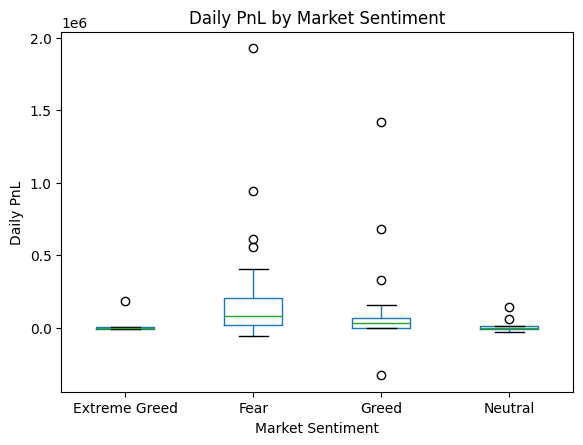

In [35]:
import matplotlib.pyplot as plt

final_df.boxplot(column='daily_pnl', by='classification', grid=False)
plt.title("Daily PnL by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.savefig("daily_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()


In [29]:
median_trades = analysis_df['trades_count'].median()

analysis_df['frequency_segment'] = analysis_df['trades_count'].apply(
    lambda x: 'Frequent' if x >= median_trades else 'Infrequent'
)

/tmp/ipython-input-1097322406.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df['frequency_segment'] = analysis_df['trades_count'].apply(


In [30]:
analysis_df.groupby(
    ['classification', 'frequency_segment']
)['daily_pnl'].mean()


classification  frequency_segment
Extreme Greed   Frequent              95224.489473
                Infrequent            -4494.495724
Fear            Frequent             265107.235726
                Infrequent            42168.941645
Greed           Frequent             258742.081901
                Infrequent            27372.532562
Neutral         Frequent               9156.505979
                Infrequent            26254.572028
Name: daily_pnl, dtype: float64

In [32]:
median_size = analysis_df['avg_trade_size'].median()

analysis_df['size_segment'] = analysis_df['avg_trade_size'].apply(
    lambda x: 'Large Size' if x >= median_size else 'Small Size'
)

/tmp/ipython-input-2488469502.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df['size_segment'] = analysis_df['avg_trade_size'].apply(


In [33]:
analysis_df.groupby('classification')['long_short_ratio'].mean()


,long_short_ratio
classification,
Extreme Greed,18.190287
Fear,0.965087
Greed,8.640119
Neutral,1.134648


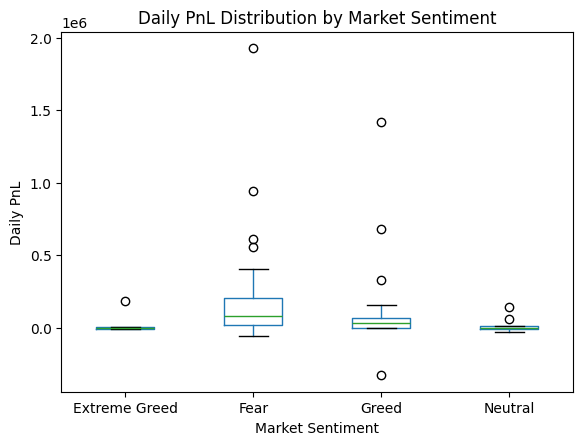

In [34]:
import matplotlib.pyplot as plt

analysis_df.boxplot(
    column='daily_pnl',
    by='classification',
    grid=False
)
plt.title("Daily PnL Distribution by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.show()


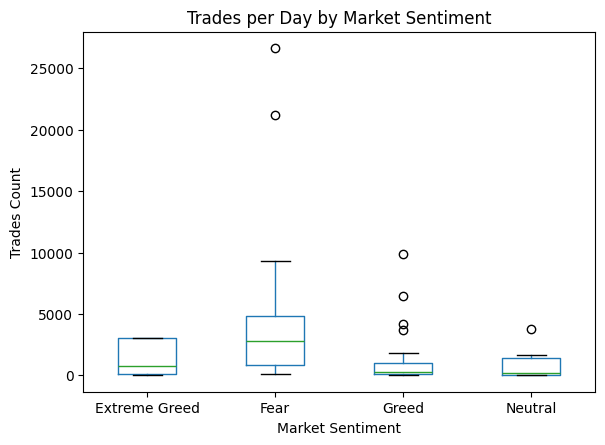

In [38]:
import os
import matplotlib.pyplot as plt

# Create the directory if it doesn't exist
output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

analysis_df.boxplot(column='trades_count', by='classification', grid=False)
plt.title("Trades per Day by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades Count")

plt.savefig(os.path.join(output_dir, "trade_frequency_by_sentiment.png"), dpi=300, bbox_inches="tight")
plt.show()

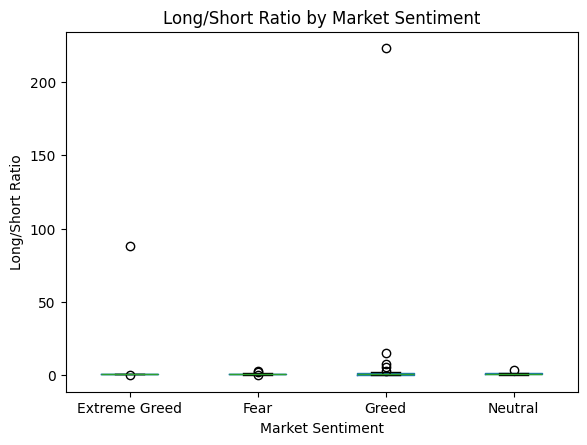

In [39]:
analysis_df.boxplot(column='long_short_ratio', by='classification', grid=False)
plt.title("Long/Short Ratio by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Long/Short Ratio")

plt.savefig("outputs/long_short_ratio_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()
